## Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math 
from random import random 
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path 
import librosa 
import json 
from collections import defaultdict

## Set up GPU 

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Setup

In [3]:
SEED = 42 
torch.manual_seed(SEED)
np.random.seed(SEED)

## Data

### KAGGLE GTZAN Dataset

In [4]:
from dotenv import load_dotenv 
load_dotenv() 
import kagglehub 

download_path = Path(kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification"))

print(f"download path: {download_path}")
print(f"data contents: {list(download_path.iterdir())}")

download path: /Users/pranavrajan/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1
data contents: [PosixPath('/Users/pranavrajan/.cache/kagglehub/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/versions/1/Data')]


### Constants 

In [5]:
SAMPLE_RATE = 22050
DURATION = 30  # measured in seconds
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION

### MFCC Data Preprocessing

In [6]:
from tqdm import tqdm 

def save_mfcc(dataset_path, json_path, n_mfcc=13, n_fft=2048, hop_length=512, num_segments=5):
    # dictionary to store data
    data = {
        # genres
        "mapping": [],
        # mfcc vectors for each of the segments - the training inputs
        "mfcc": [],
        # the target variables
        "labels": [],
    }
 
    num_samples_per_segment = int(SAMPLES_PER_TRACK / num_segments)
    expected_num_mfcc_vectors_per_segment = math.ceil(num_samples_per_segment / hop_length)  # 1.2 => 2
 
    # loop through all the genre folders (one level down from dataset_path)
    # sorted() makes the label order deterministic across machines
    genre_dirs = sorted(p for p in dataset_path.iterdir() if p.is_dir())
 
    for i, genre_dir in enumerate(genre_dirs):
        # save the semantic label (e.g. "blues")
        semantic_label = genre_dir.name
        data["mapping"].append(semantic_label)
        # .glob("*.wav") automatically skips hidden files like .DS_Store
        wav_files = sorted(genre_dir.glob("*.wav"))
 
        # process all wav files for current genre
        for file_path in tqdm(wav_files, desc=f"{semantic_label:10s}", leave=True):
            # some GTZAN files are corrupted (e.g. jazz.00054) - skip them
            try:
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            except Exception as e:
                tqdm.write(f"Skipping corrupted file {file_path.name}")
                continue
 
            # process segments extracting mfcc and storing data
            # s - current segment we are in. slide to the right the number of samples per segment
            for s in range(num_segments):
                start_sample = num_samples_per_segment * s  # s=0 => 0
                end_sample = start_sample + num_samples_per_segment # s=0 => num_samples_per_segment

                # returns a matrix (mfcc, time)
                mfcc = librosa.feature.mfcc(
                    y=signal[start_sample:end_sample],
                    sr=sr,
                    n_fft=n_fft,
                    n_mfcc=n_mfcc,
                    hop_length=hop_length,
                )

                # convert to (time, mfcc) for deep learning 
                mfcc = mfcc.T
 
                # store mfcc for segment if it has the expected length
                if len(mfcc) == expected_num_mfcc_vectors_per_segment:
                    data["mfcc"].append(mfcc.tolist())
                    data["labels"].append(i)
 
    # make sure the output directory exists before writing
    json_path.parent.mkdir(parents=True, exist_ok=True)
 
    with open(json_path, "w") as fp:
        json.dump(data, fp, indent=4)

In [7]:
json_path = Path("data/mfcc_data.json")
dataset_path = download_path / "Data" / "genres_original"
save_mfcc(dataset_path, json_path, num_segments=10)

jazz      :  54%|████████████████▏             | 54/100 [00:01<00:00, 52.09it/s]/var/folders/73/y8z3_15n0c3fnwk5fkhj6ql40000gn/T/ipykernel_11101/2706401927.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/Users/pranavrajan/Desktop/ml-engineering-practice/.venv/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
jazz      :  60%|██████████████████            | 60/100 [00:01<00:01, 33.46it/s]

Skipping corrupted file jazz.00054.wav


rock      : 100%|█████████████████████████████| 100/100 [00:02<00:00, 49.80it/s]


## Dataset Processing

### Data Loading

In [8]:
import json 

# load data 
def load_data(dataset_path):
    with open(dataset_path, "r") as f:
        data = json.load(f)

    # convert lists into numpy arrays 
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])
    mapping = data["mapping"]
    
    return inputs, targets, mapping

### Create Datasets

In [9]:
def prepare_datasets(data_path, test_size, valid_size):
    # load data 
    X, y, mapping = load_data(data_path)

    # create train/test split 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=SEED)
    
    # create train/validation split 
    X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=valid_size, random_state=SEED)

    # 130 - time bins 
    # 13 - # mfcc coeffs
    # 1 - channel(depth greyscale images)
    # 3d array -> (130, 13, 1)
    # X_train = X_train[:, np.newaxis, :, :] # 4d array -> (num_samples, 130, 13, 1)
    # X_valid = X_valid[:, np.newaxis, :, :] # 4d array -> (num_samples, 130, 13, 1)
    # X_test = X_test[:, np.newaxis, :, :] # 4d array -> (num_samples, 130, 13, 1)

    return X_train, X_valid, X_test, y_train, y_valid, y_test, mapping

In [10]:
# split the data into train and test sets
X_train, X_valid, X_test, y_train, y_valid, y_test, mapping = prepare_datasets(json_path, 0.25, 0.2)

X_train = torch.from_numpy(X_train).float() 
X_valid = torch.from_numpy(X_valid).float() 
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long() 
y_valid = torch.from_numpy(y_valid).long() 
y_test = torch.from_numpy(y_test).long() 

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

## Neural Network Architecture - Recurrent Neural Networks(RNN) Long Short-Term Memory (LSTM)

In [ ]:
# neural network architecture 
class MusicGenreClassifier(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2,
                 num_classes=10, dropout_prob=0.3):
        super().__init__()
        
        # build a model
        # 2 LSTM layers
        self.net = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # dense layer + output layer 
        self.dense = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout_prob), 
            nn.Linear(64, num_classes),
        )
        
    def forward(self, x):
        output, (h_n, c_n) = self.net(x)
        x = output.mean(dim=1)
        # x = output[:, -1, :]
        return self.dense(x)

def train(model, train_dataloader, valid_dataloader, optimizer, loss_fn, device, epochs=50):
    history = defaultdict(list)
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x_batch, y_batch in train_dataloader:
            # get a sample of data 
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            # set the gradients to 0 
            optimizer.zero_grad()
            
            # run forward pass
            preds = model(x_batch)
            
            # run cross entropy loss
            loss = loss_fn(preds, y_batch)
            
            # run backward pass
            loss.backward()
            
            # update parameters
            optimizer.step()
 
            # accumulate training loss
            train_loss += loss.item() * x_batch.size(0)
 
            # number of correct predictions in batch
            train_correct += (preds.argmax(1) == y_batch).sum().item()
 
            # number of samples in the batch
            train_total += y_batch.size(0)
 
        # check the model accuracy once per epoch on the validation data
        valid_loss, valid_acc = evaluate(model, valid_dataloader, loss_fn, device)
 
        # update the training statistics
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(train_correct / train_total)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)
 
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss / train_total:.4f} - train_acc: {train_correct / train_total:.4f} | "
            f"valid_loss: {valid_loss:.4f} - valid_acc: {valid_acc:.4f}"
        )
 
    print("---------------------------------------")
    print("Training Finished!\n")

    return history


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            correct += (preds.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
 
    return total_loss / total, correct / total

## Overfitting Debugging

In [12]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))
 
    # create accuracy subplot
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["valid_acc"], label="valid accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")
 
    # create error subplot
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["valid_loss"], label="valid error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")
 
    fig.tight_layout()
    plt.show()

## Neural Networks go brrrrrr...... 

### Training Setup

In [13]:
# compile network 
model = MusicGenreClassifier().to(device)

# weight_decay = l2 regularization in pytorch 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)

# loss function
loss_fn = nn.CrossEntropyLoss()

# train network 
model_training_history = train(model, train_dataloader, valid_dataloader, optimizer, loss_fn, device, epochs=50)

Epoch 1/50 | train_loss: 2.0813 - train_acc: 0.2964 | valid_loss: 1.7106 - valid_acc: 0.4126
Epoch 2/50 | train_loss: 1.5689 - train_acc: 0.4487 | valid_loss: 1.3717 - valid_acc: 0.5280
Epoch 3/50 | train_loss: 1.3598 - train_acc: 0.5213 | valid_loss: 1.2502 - valid_acc: 0.5768
Epoch 4/50 | train_loss: 1.2474 - train_acc: 0.5610 | valid_loss: 1.1662 - valid_acc: 0.6008
Epoch 5/50 | train_loss: 1.1441 - train_acc: 0.6004 | valid_loss: 1.0876 - valid_acc: 0.6255
Epoch 6/50 | train_loss: 1.0806 - train_acc: 0.6258 | valid_loss: 1.0508 - valid_acc: 0.6335
Epoch 7/50 | train_loss: 1.0094 - train_acc: 0.6548 | valid_loss: 1.0027 - valid_acc: 0.6549
Epoch 8/50 | train_loss: 0.9510 - train_acc: 0.6732 | valid_loss: 0.9615 - valid_acc: 0.6649
Epoch 9/50 | train_loss: 0.9128 - train_acc: 0.6857 | valid_loss: 0.9864 - valid_acc: 0.6615
Epoch 10/50 | train_loss: 0.8868 - train_acc: 0.7022 | valid_loss: 0.9064 - valid_acc: 0.6896
Epoch 11/50 | train_loss: 0.8110 - train_acc: 0.7263 | valid_loss: 0.

### Overfitting Debugging

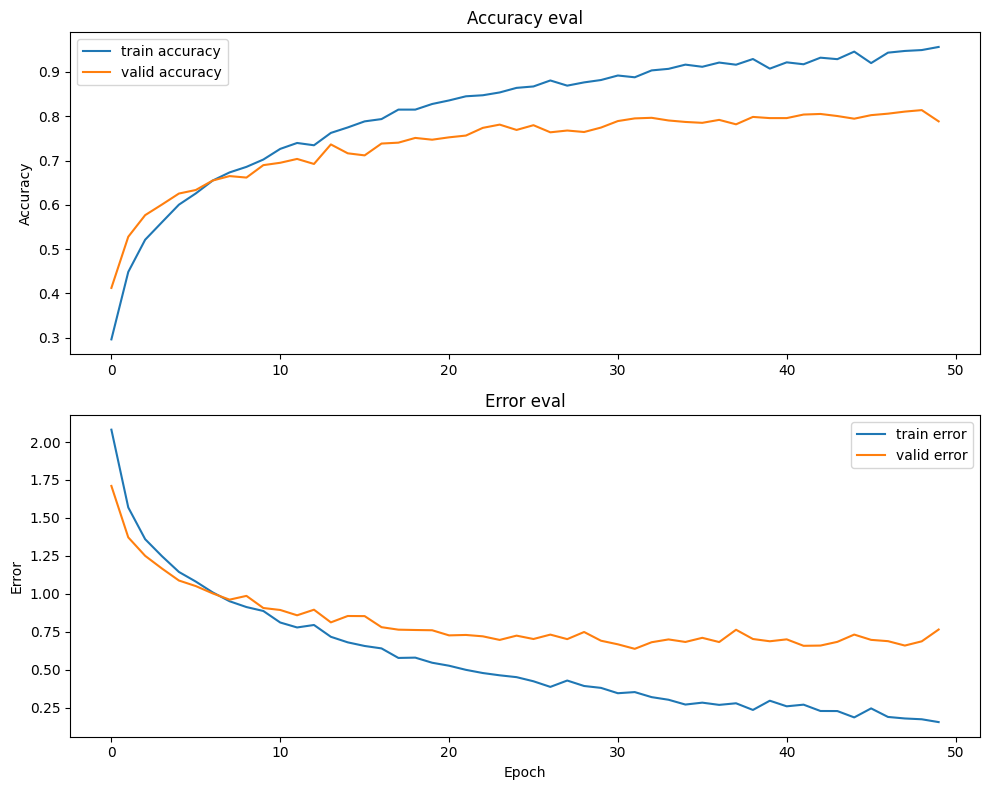

In [14]:
# plot accuracy and error over the epochs 
plot_history(model_training_history) 

### Evaluation 

In [15]:
test_loss, test_acc = evaluate(model, test_dataloader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.7961 | Test accuracy: 0.7841


## Inference

In [16]:
def predict(model, X, y):
    X = X.unsqueeze(0).to(device)
    model.eval() 
    with torch.no_grad():
        logits = model(X)
        predicted_class = logits.argmax(1).item()

    target_genre = mapping[y.item()]
    predicted_genre = mapping[predicted_class]
    print(f"Prediction: {predicted_class} - {predicted_genre} | Target: {y.item()} - {target_genre}")

In [17]:
X, y = test_dataset[100]
predict(model, X, y)

Prediction: 4 - hiphop | Target: 4 - hiphop
